In [1]:
import pandas as pd
import torch 
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader

In [2]:
raw_data = pd.read_csv('../data/btcusd_1-min_data.csv',index_col=0)

In [3]:
from preprocess import prepare_intraday_data, calculate_daily_components
intraday_data = prepare_intraday_data(raw_data) 
daily_data = calculate_daily_components(intraday_data)
from dataloader import create_dataloaders
# 创建DataLoader
train_loader, test_loader = create_dataloaders(daily_data, batch_size=32)

Train shape: (4096, 1, 16, 16)
Test shape:  (1024, 1, 16, 16)


In [4]:
# 检查DataLoader的基本信息
print(f"训练集batch数量: {len(train_loader)}")
print(f"测试集batch数量: {len(test_loader)}")

# 获取一个batch的数据（多任务：图像、回归标签、分类标签）
images, y_reg, y_cls = next(iter(train_loader))
print(f"单个batch图像形状: {images.shape}")  # 应该是 [batch_size, 1, 16, 16]
print(f"单个batch回归标签形状: {y_reg.shape}")
print(f"单个batch分类标签形状: {y_cls.shape}")
print(f"回归标签示例 (前5个): {y_reg[:5].numpy()}")
print(f"分类标签示例 (前10个): {y_cls[:10].numpy()}")

# 检查类别分布
all_cls_labels = []
for _, _, batch_cls_labels in train_loader:
    all_cls_labels.append(batch_cls_labels.numpy())
all_cls_labels = np.concatenate(all_cls_labels)
print(f"训练集分类类别分布 - 0: {(all_cls_labels == 0).sum()}, 1: {(all_cls_labels == 1).sum()}")

# 检查回归标签统计
all_reg_labels = []
for _, batch_reg_labels, _ in train_loader:
    all_reg_labels.append(batch_reg_labels.numpy())
all_reg_labels = np.concatenate(all_reg_labels)
print(f"训练集回归标签统计 - 均值: {all_reg_labels.mean():.4f}, 标准差: {all_reg_labels.std():.4f}, 范围: [{all_reg_labels.min():.4f}, {all_reg_labels.max():.4f}]")

训练集batch数量: 128
测试集batch数量: 32
单个batch图像形状: torch.Size([32, 1, 16, 16])
单个batch回归标签形状: torch.Size([32])
单个batch分类标签形状: torch.Size([32])
回归标签示例 (前5个): [-0.08208517 -0.06794553 -0.09543647  0.36333582 -0.15905632]
分类标签示例 (前10个): [1 0 1 1 1 1 0 0 1 1]
训练集分类类别分布 - 0: 1850, 1: 2246
训练集回归标签统计 - 均值: 0.0000, 标准差: 1.0000, 范围: [-0.1802, 36.4897]


In [5]:
# 导入CNN模型和训练函数
from model import CNN_HAR_KS, train_model, evaluate_model
# 设置设备并实例化模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 创建模型实例
model = CNN_HAR_KS().to(device)

# 检查模型结构
print("模型结构:")
print(model)

# 计算参数数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"总参数数量: {total_params:,}")
print(f"可训练参数数量: {trainable_params:,}")

# 使用一个batch测试前向传播（多任务）
images, y_reg, y_cls = next(iter(train_loader))
images = images.to(device)
y_reg = y_reg.to(device)
y_cls = y_cls.to(device)

with torch.no_grad():
    reg_output, cls_output = model(images)
    print(f"\n测试前向传播（多任务）:")
    print(f"输入形状: {images.shape}")
    print(f"回归输出形状: {reg_output.shape}")
    print(f"分类输出形状: {cls_output.shape}")
    # 分类预测：使用sigmoid激活和阈值0.5
    cls_pred = (torch.sigmoid(cls_output) > 0.5).long().squeeze()
    print(f"分类预测: {cls_pred[:10].cpu().numpy()}")
    print(f"真实分类标签: {y_cls[:10].cpu().numpy()}")
    print(f"真实回归标签示例: {y_reg[:5].cpu().numpy()}")

使用设备: cuda
模型结构:
CNN_HAR_KS(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=4096, out_features=64, bias=True)
  (relu3): ReLU()
  (fc_reg): Linear(in_features=64, out_features=1, bias=True)
  (fc_cls): Linear(in_features=64, out_features=1, bias=True)
)
总参数数量: 281,154
可训练参数数量: 281,154

测试前向传播（多任务）:
输入形状: torch.Size([32, 1, 16, 16])
回归输出形状: torch.Size([32, 1])
分类输出形状: torch.Size([32, 1])
分类预测: [1 1 1 1 1 1 1 1 1 1]
真实分类标签: [1 0 0 1 0 0 1 1 0 1]
真实回归标签示例: [-0.17620665 -0.15103206 -0.02567158 -0.11041122  1.998297  ]


In [6]:
# 训练多任务模型
print("开始训练多任务模型...")
num_epochs = 50  # 可以根据需要调整

history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    num_epochs=num_epochs,
    device=device
)

print("\n多任务训练完成!")
print(f"最终测试损失: {history['test_loss'][-1]:.4f}")
print(f"最终测试回归MSE: {history['test_reg_mse'][-1]:.4f}")
print(f"最终测试分类准确率: {history['test_cls_acc'][-1]:.4f}")

开始训练多任务模型...
Starting multi-task training on cuda...
Epoch [1/50] Loss: 1.1213 | Train Reg MSE: 0.8596 | Train Cls Acc: 0.5464 | Test Loss: 0.7031 | Test Reg MSE: 0.0200 | Test Cls Acc: 0.5098
Epoch [2/50] Loss: 1.0803 | Train Reg MSE: 0.7805 | Train Cls Acc: 0.5417 | Test Loss: 0.6928 | Test Reg MSE: 0.0016 | Test Cls Acc: 0.5098
Epoch [3/50] Loss: 1.0657 | Train Reg MSE: 0.7655 | Train Cls Acc: 0.5498 | Test Loss: 0.6944 | Test Reg MSE: 0.0045 | Test Cls Acc: 0.5098
Epoch [4/50] Loss: 1.0160 | Train Reg MSE: 0.6676 | Train Cls Acc: 0.5515 | Test Loss: 0.6934 | Test Reg MSE: 0.0038 | Test Cls Acc: 0.5127
Epoch [5/50] Loss: 0.9909 | Train Reg MSE: 0.6206 | Train Cls Acc: 0.5576 | Test Loss: 0.6912 | Test Reg MSE: 0.0022 | Test Cls Acc: 0.5127
Epoch [6/50] Loss: 0.9685 | Train Reg MSE: 0.5843 | Train Cls Acc: 0.5608 | Test Loss: 0.6949 | Test Reg MSE: 0.0084 | Test Cls Acc: 0.5098
Epoch [7/50] Loss: 0.9491 | Train Reg MSE: 0.5663 | Train Cls Acc: 0.5872 | Test Loss: 0.6853 | Test Reg MS

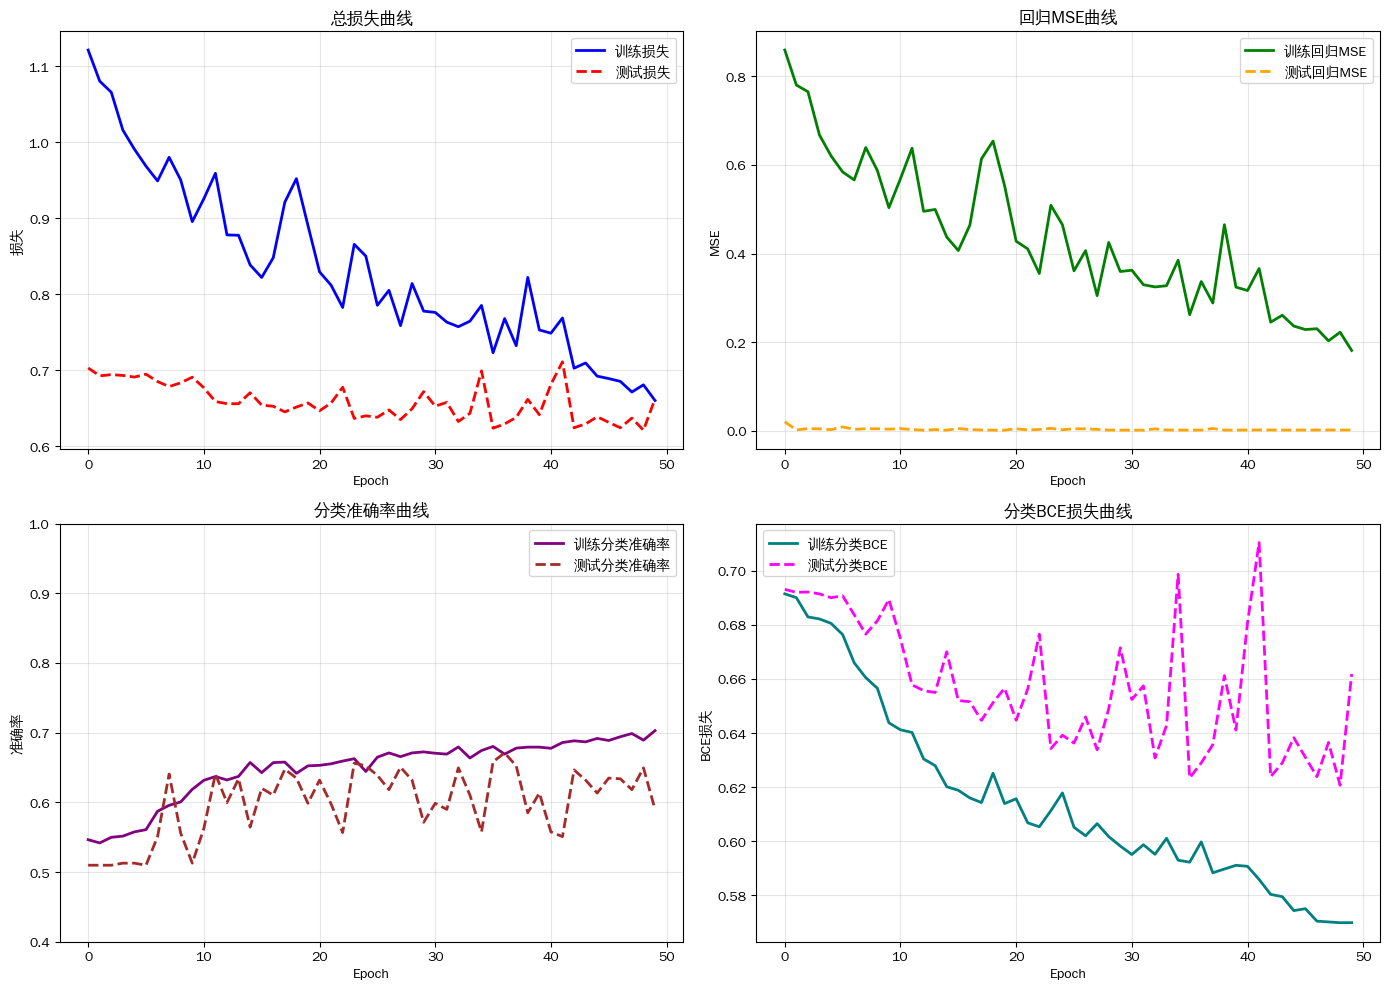

最佳测试分类准确率: 0.6709 (Epoch 37)
最佳测试回归MSE: 0.0009 (Epoch 13)
对应训练损失: 0.7681
当前 matplotlib 中文字体: WenQuanYi Zen Hei
多任务模型已保存为 cnn_har_ks_multitask_model.pth


In [7]:
# 可视化多任务训练结果
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 为 matplotlib 选择一个可用的中文字体，避免中文标题和标签告警
font_candidates = [
    'Noto Sans CJK SC',
    'WenQuanYi Zen Hei',
    'Droid Sans Fallback',
    'SimHei',
    'Microsoft YaHei',
]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
selected_font = next((font for font in font_candidates if font in available_fonts), None)
if selected_font:
    plt.rcParams['font.sans-serif'] = [selected_font, *plt.rcParams.get('font.sans-serif', [])]
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 绘制总损失曲线
axes[0, 0].plot(history['train_loss'], label='训练损失', color='blue', linewidth=2)
axes[0, 0].plot(history['test_loss'], label='测试损失', color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('损失')
axes[0, 0].set_title('总损失曲线')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2. 绘制回归MSE曲线
axes[0, 1].plot(history['train_reg_mse'], label='训练回归MSE', color='green', linewidth=2)
axes[0, 1].plot(history['test_reg_mse'], label='测试回归MSE', color='orange', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MSE')
axes[0, 1].set_title('回归MSE曲线')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# 3. 绘制分类准确率曲线
axes[1, 0].plot(history['train_cls_acc'], label='训练分类准确率', color='purple', linewidth=2)
axes[1, 0].plot(history['test_cls_acc'], label='测试分类准确率', color='brown', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('准确率')
axes[1, 0].set_title('分类准确率曲线')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()
axes[1, 0].set_ylim([0.4, 1.0])

# 4. 绘制分类BCE损失曲线
axes[1, 1].plot(history['train_cls_bce'], label='训练分类BCE', color='teal', linewidth=2)
axes[1, 1].plot(history['test_cls_bce'], label='测试分类BCE', color='magenta', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('BCE损失')
axes[1, 1].set_title('分类BCE损失曲线')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 打印最佳结果
best_epoch_cls = np.argmax(history['test_cls_acc'])
best_epoch_reg = np.argmin(history['test_reg_mse'])
print(f"最佳测试分类准确率: {history['test_cls_acc'][best_epoch_cls]:.4f} (Epoch {best_epoch_cls+1})")
print(f"最佳测试回归MSE: {history['test_reg_mse'][best_epoch_reg]:.4f} (Epoch {best_epoch_reg+1})")
print(f"对应训练损失: {history['train_loss'][best_epoch_cls]:.4f}")
if selected_font:
    print(f"当前 matplotlib 中文字体: {selected_font}")
else:
    print("未检测到可用中文字体，图表中文可能仍然无法正常显示。")

# 保存模型（可选）
torch.save(model.state_dict(), 'cnn_har_ks_multitask_model.pth')
print("多任务模型已保存为 cnn_har_ks_multitask_model.pth")